In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
CIFAR-10 Color Diffusion (DDPM) — Markov Chains, Step-by-Step
=============================================================

What this script does
---------------------
1) Loads CIFAR-10 (color, 32x32x3) and trains a tiny DDPM.
2) Prints *theoretical concepts* as it runs:
   • Forward Markov chain: fixed Gaussian noising q(x_t|x_{t-1}) and its closed form.
   • Reverse Markov chain: learned Gaussian step p_θ(x_{t-1}|x_t) via ε-prediction.
   • Why the Markov property matters in both directions.
3) Shows and saves images:
   • Forward snapshots (clean color images → progressively noisy).
   • Noisy inputs vs. Denoised outputs (side by side).
   • Samples from noise after each epoch (reverse chain).
4) Optional: pick a *custom color image* (–-image_path) for the forward demo.

Notebook tip
------------
Use `%run cifar_ddpm_markov_color.py --show ...` (IPython magic) to display
images inline. Using `!python ...` will **save** images but not display inline.

Quick start
-----------
pip install torch torchvision matplotlib pillow
%run cifar_ddpm_markov_color.py --epochs 1 --samples 25 --show --explain --export_html
"""

import os, math, random, glob
from dataclasses import dataclass
from typing import Optional, List

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision as tv
from torchvision.utils import save_image, make_grid
from PIL import Image
import matplotlib.pyplot as plt


# ----------------------------
# Reproducibility & utils
# ----------------------------

def set_seed(s=0):
    random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.benchmark = True

def ensure_dir(p: str):
    os.makedirs(p, exist_ok=True)

@dataclass
class DiffusionSchedule:
    betas: torch.Tensor
    alphas: torch.Tensor
    abar: torch.Tensor

def schedule_linear(T=200, beta_start=1e-4, beta_end=2e-2, device="cpu"):
    betas = torch.linspace(beta_start, beta_end, T, device=device, dtype=torch.float32)
    alphas = 1.0 - betas
    abar = torch.cumprod(alphas, dim=0)
    return DiffusionSchedule(betas, alphas, abar)

def extract(a: torch.Tensor, t: torch.Tensor, shape):
    t = torch.clamp(t, 0, a.shape[0]-1)
    out = a.gather(-1, t)
    return out.view(-1, *([1]*(len(shape)-1)))

def to01(x: torch.Tensor):
    return (x.clamp(-1,1) + 1) * 0.5


# ----------------------------
# Time embedding
# ----------------------------

class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim=128, max_period=10000):
        super().__init__()
        self.dim = dim; self.max_period = max_period
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(self.max_period) * torch.arange(0, half, device=t.device) / half)
        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
        emb = torch.cat([torch.cos(args), torch.sin(args)], dim=1)
        if self.dim % 2 == 1:
            emb = F.pad(emb, (0,1))
        return emb


# ----------------------------
# Tiny color UNet-ish ε-predictor
# ----------------------------

class ResBlock(nn.Module):
    def __init__(self, ci, co, tdim):
        super().__init__()
        self.c1 = nn.Conv2d(ci, co, 3, padding=1)
        self.c2 = nn.Conv2d(co, co, 3, padding=1)
        self.t  = nn.Linear(tdim, co)
        self.n1 = nn.GroupNorm(8, co)
        self.n2 = nn.GroupNorm(8, co)
        self.skip = nn.Conv2d(ci, co, 1) if ci != co else nn.Identity()
    def forward(self, x, t_emb):
        h = self.c1(x)
        h = self.n1(h + self.t(t_emb).unsqueeze(-1).unsqueeze(-1))
        h = F.silu(h)
        h = self.c2(h)
        h = self.n2(h)
        h = F.silu(h)
        return h + self.skip(x)

class TinyColorUNet(nn.Module):
    def __init__(self, in_ch=3, base=64, tdim=128):
        super().__init__()
        self.t_embed = SinusoidalTimeEmbedding(tdim)
        self.enc1 = ResBlock(in_ch, base, tdim)
        self.enc2 = ResBlock(base, base*2, tdim)
        self.down = nn.Conv2d(base*2, base*2, 4, stride=2, padding=1)  # 32 -> 16
        self.mid  = ResBlock(base*2, base*2, tdim)
        self.up   = nn.ConvTranspose2d(base*2, base*2, 4, stride=2, padding=1)  # 16 -> 32
        self.dec2 = ResBlock(base*2, base, tdim)
        self.out  = nn.Conv2d(base, in_ch, 3, padding=1)
    def forward(self, x, t):
        te = self.t_embed(t)
        h1 = self.enc1(x, te)
        h2 = self.enc2(h1, te)
        h3 = self.down(h2)
        h4 = self.mid(h3, te)
        h5 = self.up(h4)
        h5 = h5 + F.interpolate(h2, size=h5.shape[-2:], mode="nearest")
        h6 = self.dec2(h5, te)
        return self.out(h6)  # predicts ε


# ----------------------------
# Forward & Reverse (Markov steps)
# ----------------------------

@torch.no_grad()
def q_sample(x0, t, sch: DiffusionSchedule, noise=None):
    # Forward Markov chain (fixed Gaussian):
    # x_t = sqrt(abar_t)*x0 + sqrt(1-abar_t)*ε
    if noise is None:
        noise = torch.randn_like(x0)
    abar = extract(sch.abar, t, x0.shape)
    return abar.sqrt()*x0 + (1.0-abar).sqrt()*noise

def p_mean_var(model, x_t, t, sch: DiffusionSchedule):
    # Reverse Markov chain (learned Gaussian):
    # μ_θ = (1/√α_t) * ( x_t - ((1-α_t)/√(1-ᾱ_t)) * ε_θ )
    # σ_t^2 = β_t * (1-ᾱ_{t-1})/(1-ᾱ_t)
    eps = model(x_t, t)
    a   = extract(sch.alphas, t, x_t.shape)
    abar= extract(sch.abar,   t, x_t.shape)
    beta= extract(sch.betas,  t, x_t.shape)
    abar_prev = extract(sch.abar, t-1, x_t.shape)
    coef = (1.0 - a) / (1.0 - abar).sqrt()
    mu = (1.0 / a.sqrt()) * (x_t - coef * eps)
    var = beta * (1.0 - abar_prev) / (1.0 - abar)
    return mu, var

@torch.no_grad()
def p_step(model, x_t, t, sch: DiffusionSchedule, verbose=False, milestones=None):
    mu, var = p_mean_var(model, x_t, t, sch)
    if verbose and milestones and int(t[0].item()) in milestones:
        print(f"[Reverse step] t={int(t[0].item())}: x_(t-1) ~ N(μ_θ(x_t,t), σ_t^2 I). "
              f"Markov: depends only on x_t (and fresh Gaussian).")
    if (t == 0).all():
        return mu
    return mu + var.sqrt() * torch.randn_like(x_t)

@torch.no_grad()
def sample_from_noise(model, n, img_size, sch: DiffusionSchedule, device, save_path=None, explain=False):
    T = sch.betas.shape[0]
    x = torch.randn(n, 3, img_size, img_size, device=device)
    milestones = {T-1, T//2, 10, 0}
    if explain:
        print("\n[Sampling — Reverse Markov Chain]")
        print("Start from x_T ~ N(0, I). Iterate t=T..1 using p_θ(x_{t-1}|x_t).")
    for ti in reversed(range(T)):
        t = torch.full((n,), ti, device=device, dtype=torch.long)
        x = p_step(model, x, t, sch, verbose=explain, milestones=milestones)
    x01 = to01(x)
    if save_path:
        grid = make_grid(x01, nrow=int(math.sqrt(n)))
        save_image(grid, save_path)
        if explain:
            print(f"[Saved] Samples grid → {save_path}")
    return x01


# ----------------------------
# Visualization helpers
# ----------------------------

def show_grid(imgs01: torch.Tensor, title="", nrow=5, show=True, save_path: Optional[str]=None):
    grid = make_grid(imgs01, nrow=nrow)
    plt.figure(figsize=(min(12, nrow*2.2), 2.4 + (imgs01.size(0)//nrow)*2.2))
    plt.imshow(grid.permute(1,2,0).cpu().numpy())
    plt.axis("off"); plt.title(title)
    if save_path:
        ensure_dir(os.path.dirname(save_path))
        plt.savefig(save_path, bbox_inches="tight", dpi=150)
    if show:
        plt.show()
    plt.close()

@torch.no_grad()
def visualize_forward_color(x0_batch: torch.Tensor,
                            sch: DiffusionSchedule,
                            steps: List[int],
                            out_dir: str,
                            prefix: str,
                            show: bool):
    """
    Build a panel: rows = images; columns = [x0, xt@t1, xt@t2, ...]
    """
    ensure_dir(out_dir)
    x0 = x0_batch[:6]  # 6 rows looks neat
    cols = 1 + len(steps)
    rows = x0.size(0)
    tiles = []
    for i in range(rows):
        row = [x0[i:i+1]]
        for s in steps:
            t = torch.full((1,), int(s), device=x0.device, dtype=torch.long)
            xt = q_sample(x0[i:i+1], t, sch)
            row.append(xt)
        tiles.append(torch.cat(row, dim=0))  # [cols,3,32,32]
    panel = torch.cat(tiles, dim=0)  # [rows*cols,3,32,32]
    title = f"Forward diffusion (clean → noisy). Columns: x0, t={steps}"
    save_path = os.path.join(out_dir, f"{prefix}_forward_panel.png")
    show_grid(to01(panel), title=title, nrow=cols, show=show, save_path=save_path)

@torch.no_grad()
def visualize_noisy_vs_denoised(model,
                                sch: DiffusionSchedule,
                                x0_batch: torch.Tensor,
                                t_start: int,
                                out_dir: str,
                                prefix: str,
                                show: bool):
    """
    Save/show: noisy inputs at t_start and the denoised results to t=0.
    """
    ensure_dir(out_dir)
    x0 = x0_batch[:10]
    t  = torch.full((x0.size(0),), t_start, device=x0.device, dtype=torch.long)
    x_noisy = q_sample(x0, t, sch)
    # Denoise to x_0 by running reverse chain
    x = x_noisy.clone()
    for ti in reversed(range(t_start+1)):
        t_i = torch.full((x.size(0),), ti, device=x.device, dtype=torch.long)
        x   = p_step(model, x, t_i, sch)
    x_denoised = to01(x)

    show_grid(to01(x_noisy), f"Noisy inputs at t={t_start}", nrow=5, show=show,
              save_path=os.path.join(out_dir, f"{prefix}_noisy_t{t_start}.png"))
    show_grid(x_denoised, "Denoised outputs (reverse Markov chain)", nrow=5, show=show,
              save_path=os.path.join(out_dir, f"{prefix}_denoised_from_t{t_start}.png"))

def export_html(out_dir):
    imgs = sorted(glob.glob(os.path.join(out_dir, "*.png")))
    if not imgs:
        return
    html = ["<html><body><h2>Color DDPM Outputs</h2>"]
    for p in imgs:
        html += [f"<div><b>{os.path.basename(p)}</b><br>",
                 f"<img src='{os.path.basename(p)}' width='512'></div><hr>"]
    html += ["</body></html>"]
    with open(os.path.join(out_dir, "index.html"), "w") as f:
        f.write("\n".join(html))
    print(f"[Gallery] Wrote {os.path.join(out_dir,'index.html')}")


# ----------------------------
# Data helpers (CIFAR-10 & custom image)
# ----------------------------

def get_cifar10(data_dir="./data", limit_train: int = 50000, limit_test: int = 10000):
    to_tensor = tv.transforms.ToTensor()
    tfm = tv.transforms.Compose([
        to_tensor,
        tv.transforms.Lambda(lambda x: x*2-1)  # [-1,1]
    ])
    train = tv.datasets.CIFAR10(root=data_dir, train=True, download=True, transform=tfm)
    test  = tv.datasets.CIFAR10(root=data_dir, train=False, download=True, transform=tfm)

    if limit_train < len(train):
        train = Subset(train, range(limit_train))
    if limit_test < len(test):
        test  = Subset(test, range(limit_test))
    return train, test

def load_custom_color_image(path: str, device, size=32):
    img = Image.open(path).convert("RGB").resize((size, size), Image.BICUBIC)
    x = tv.transforms.ToTensor()(img)         # [0,1]
    x = (x * 2.0 - 1.0).unsqueeze(0).to(device)  # [-1,1], [1,3,H,W]
    return x


# ----------------------------
# Training & main flow
# ----------------------------

def train_and_demo(
    data="./data", out="./outputs_color", epochs=1, batch_size=128, lr=2e-4,
    T=200, beta_start=1e-4, beta_end=2e-2, samples=25, show=True, explain=True,
    export_html_flag=True, seed=0, limit_train=20000, limit_test=2000,
    image_path: Optional[str]=None
):
    set_seed(seed)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Device: {device}")

    # ==== Concepts upfront ====
    if explain:
        print("\n[Concepts — Markov Chains in Diffusion]")
        print("• Forward chain q(x_t | x_{t-1}) adds small Gaussian noise at each step.")
        print("  Markov property: x_t depends ONLY on x_{t-1} (not earlier states).")
        print("  Closed form: x_t = √ᾱ_t x_0 + √(1−ᾱ_t) ε, with ε ~ N(0, I).")
        print("• Reverse chain p_θ(x_{t-1} | x_t) removes noise step-by-step.")
        print("  Markov property: x_{t-1} depends ONLY on x_t (plus fresh Gaussian).")
        print("  We train ε_θ(x_t, t) so we can compute μ_θ for the reverse Gaussian.")
        print("  Sampling: start from x_T ~ N(0, I) and iterate t=T..1 to reach x_0.\n")

    # Data
    train_set, test_set = get_cifar10(data_dir=data, limit_train=limit_train, limit_test=limit_test)
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)
    test_loader  = DataLoader(test_set,  batch_size=32, shuffle=True,  num_workers=2, drop_last=True)

    # Model & schedule
    model = TinyColorUNet(in_ch=3, base=64, tdim=128).to(device)
    sch   = schedule_linear(T=T, beta_start=beta_start, beta_end=beta_end, device=device)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr)

    ensure_dir(out)

    # Optional: forward demo on custom color image (or a batch from CIFAR)
    if explain:
        print("[Forward demo] Visualize the forward Markov chain (clean → noisy).")
    if image_path and os.path.isfile(image_path):
        print(f"Using custom color image for forward snapshots: {image_path}")
        x0_custom = load_custom_color_image(image_path, device)            # [1,3,32,32]
        x0_demo   = x0_custom.repeat(6,1,1,1)                              # make 6 copies
    else:
        x0_demo, _ = next(iter(test_loader))
        x0_demo = x0_demo.to(device)

    forward_steps = sorted({1, T//10, T//5, T//2, T-1})
    visualize_forward_color(x0_demo, sch, steps=forward_steps, out_dir=out,
                            prefix="epoch0", show=show)

    # ==== Training loop (ε-prediction objective) ====
    model.train()
    for epoch in range(1, epochs+1):
        for i, (x0, _) in enumerate(train_loader, start=1):
            x0 = x0.to(device)
            t  = torch.randint(1, T, (x0.size(0),), device=device)
            eps = torch.randn_like(x0)
            x_t = q_sample(x0, t, sch, noise=eps)     # Forward (fixed Markov step)

            eps_pred = model(x_t, t)                  # Predict ε
            loss = F.mse_loss(eps_pred, eps)          # Train ε_θ ≈ ε

            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()

            if i % 200 == 0:
                print(f"Epoch {epoch} | step {i}/{len(train_loader)} | loss {loss.item():.4f}")
                if explain and i % 400 == 0:
                    print("  [Why this works] We corrupt x0 → xt at a random t and")
                    print("  train the net to recover the exact noise ε. This teaches")
                    print("  the local reverse step p_θ(x_{t-1}|x_t).")

        # After each epoch: (1) sample from noise, (2) noisy vs. denoised, (3) forward panel again
        model.eval()
        with torch.no_grad():
            samples_path = os.path.join(out, f"samples_epoch{epoch}.png")
            print(f"[Sampling] Reverse chain from x_T: saving {samples_path}")
            _ = sample_from_noise(model, n=samples, img_size=32, sch=sch, device=device,
                                  save_path=samples_path, explain=explain)

            x0_eval, _ = next(iter(test_loader))
            x0_eval = x0_eval.to(device)
            t_start = T - 1
            visualize_noisy_vs_denoised(model, sch, x0_eval, t_start=t_start,
                                        out_dir=out, prefix=f"epoch{epoch}", show=show)

            visualize_forward_color(x0_eval, sch, steps=forward_steps, out_dir=out,
                                    prefix=f"epoch{epoch}", show=show)
        model.train()

    # Save weights and gallery
    wpath = os.path.join(out, "cifar_ddpm_tinyunet.pt")
    torch.save({"model": model.state_dict(),
                "hparams": dict(epochs=epochs, batch_size=batch_size, lr=lr, T=T,
                                beta_start=beta_start, beta_end=beta_end,
                                samples=samples, seed=seed)}, wpath)
    print(f"[Saved weights] {wpath}")

    if export_html_flag:
        export_html(out)

    print("\n[Recap]")
    print("• Forward q(x_t|x_{t-1}) is a fixed Gaussian noising process (Markov).")
    print("• Reverse p_θ(x_{t-1}|x_t) is learned via ε-prediction; sampling runs x_T→x_0 step-by-step (also Markov).")
    print(f"Images written to: {os.path.abspath(out)}")


# ----------------------------
# CLI / Notebook-friendly entry
# ----------------------------

def main():
    import argparse
    p = argparse.ArgumentParser(description="CIFAR-10 Color DDPM with explanations & visuals")
    p.add_argument("--data", type=str, default="./data")
    p.add_argument("--out", type=str, default="./outputs_color")
    p.add_argument("--epochs", type=int, default=1)
    p.add_argument("--batch_size", type=int, default=128)
    p.add_argument("--lr", type=float, default=2e-4)
    p.add_argument("--T", type=int, default=200)
    p.add_argument("--beta_start", type=float, default=1e-4)
    p.add_argument("--beta_end", type=float, default=2e-2)
    p.add_argument("--samples", type=int, default=25)
    p.add_argument("--show", action="store_true", help="display images inline with matplotlib (use %run)")
    p.add_argument("--explain", action="store_true", help="print step-by-step Markov-chain explanations")
    p.add_argument("--export_html", action="store_true", help="write outputs_color/index.html gallery")
    p.add_argument("--seed", type=int, default=0)
    p.add_argument("--limit_train", type=int, default=20000, help="cap training set for speed")
    p.add_argument("--limit_test", type=int, default=2000, help="cap test set for speed")
    p.add_argument("--image_path", type=str, default="", help="optional custom color image (forward demo)")
    args, _ = p.parse_known_args()  # ignore stray notebook args like -f

    train_and_demo(
        data=args.data, out=args.out, epochs=args.epochs, batch_size=args.batch_size, lr=args.lr,
        T=args.T, beta_start=args.beta_start, beta_end=args.beta_end, samples=args.samples,
        show=args.show, explain=args.explain, export_html_flag=args.export_html, seed=args.seed,
        limit_train=args.limit_train, limit_test=args.limit_test,
        image_path=(args.image_path if args.image_path else None)
    )

if __name__ == "__main__":
    main()


Device: cuda


100%|██████████| 170M/170M [00:13<00:00, 12.8MB/s]


[Sampling] Reverse chain from x_T: saving ./outputs_color/samples_epoch1.png
[Saved weights] ./outputs_color/cifar_ddpm_tinyunet.pt

[Recap]
• Forward q(x_t|x_{t-1}) is a fixed Gaussian noising process (Markov).
• Reverse p_θ(x_{t-1}|x_t) is learned via ε-prediction; sampling runs x_T→x_0 step-by-step (also Markov).
Images written to: /content/outputs_color


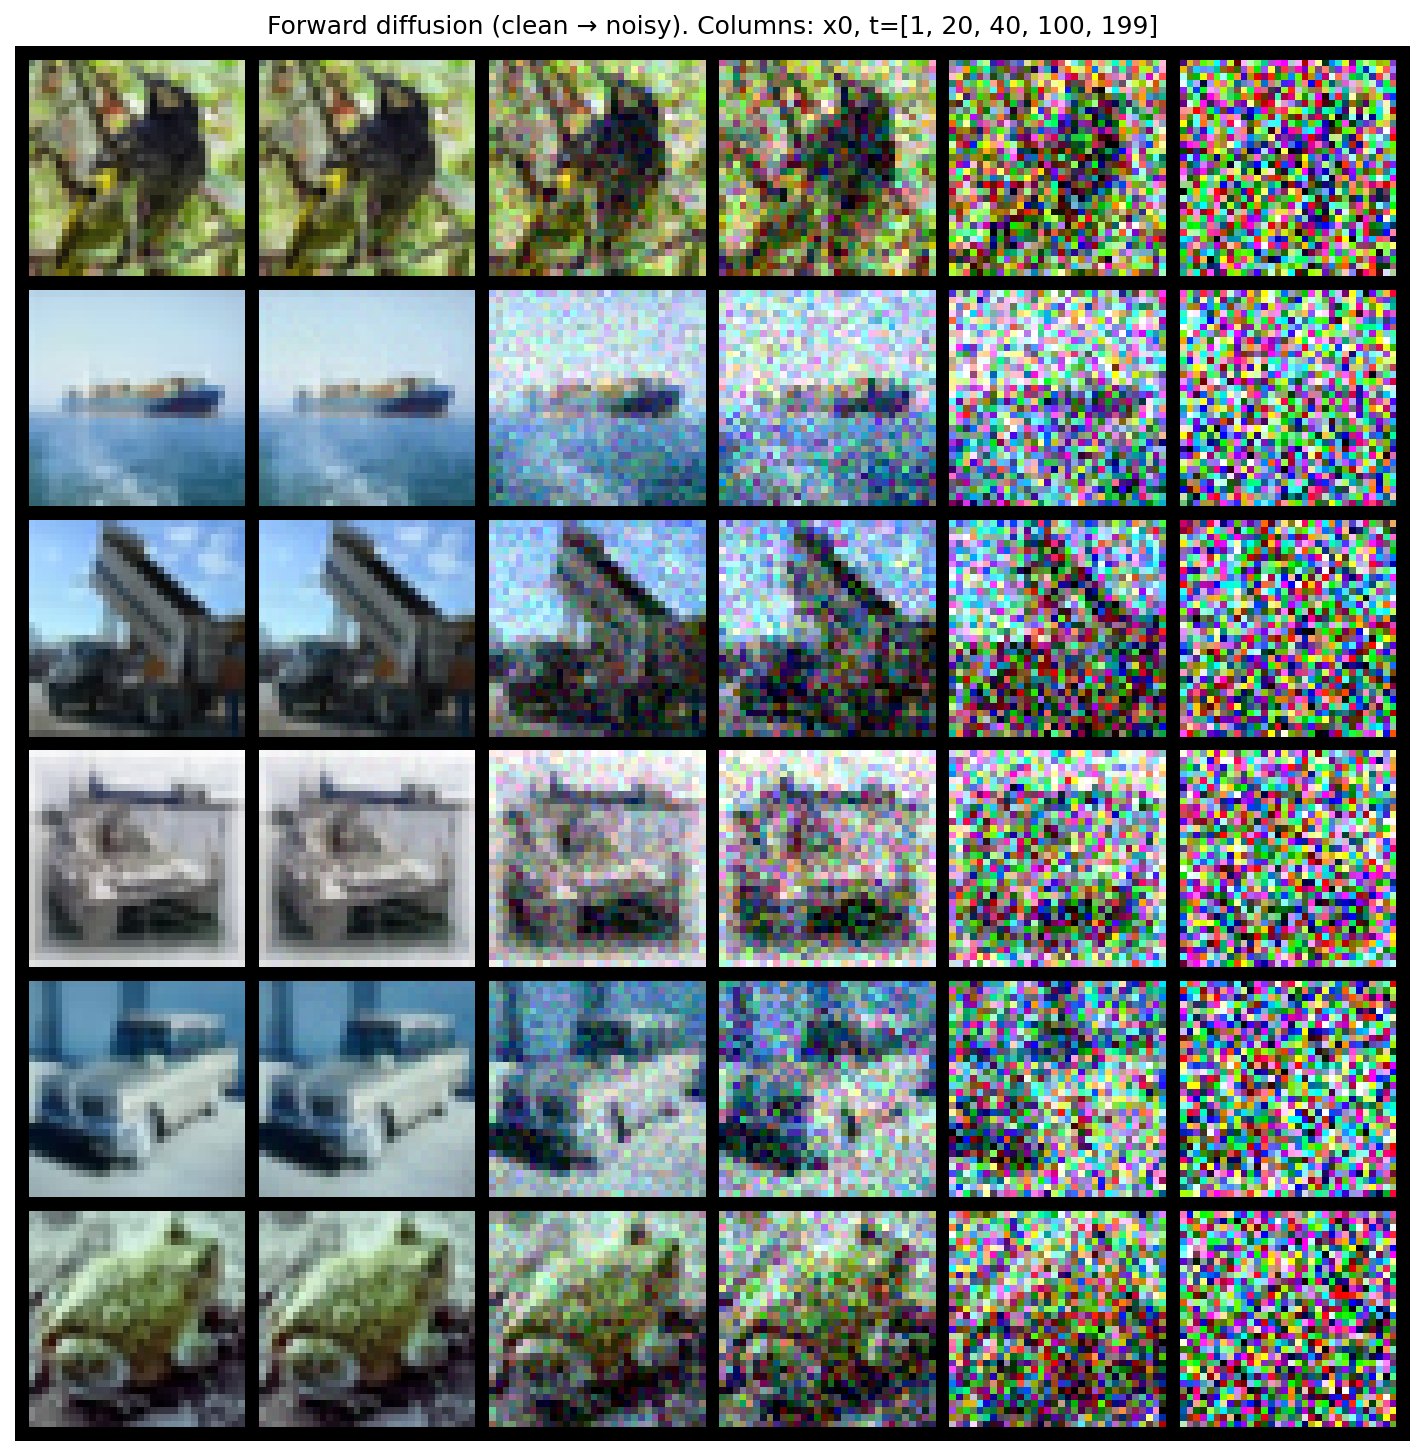

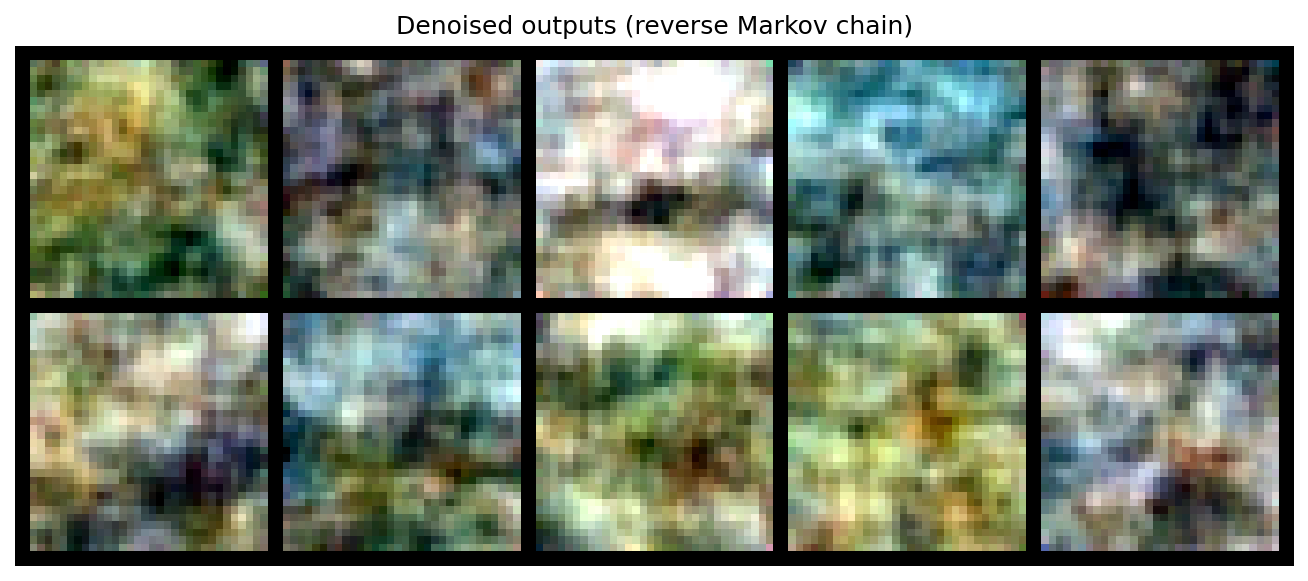

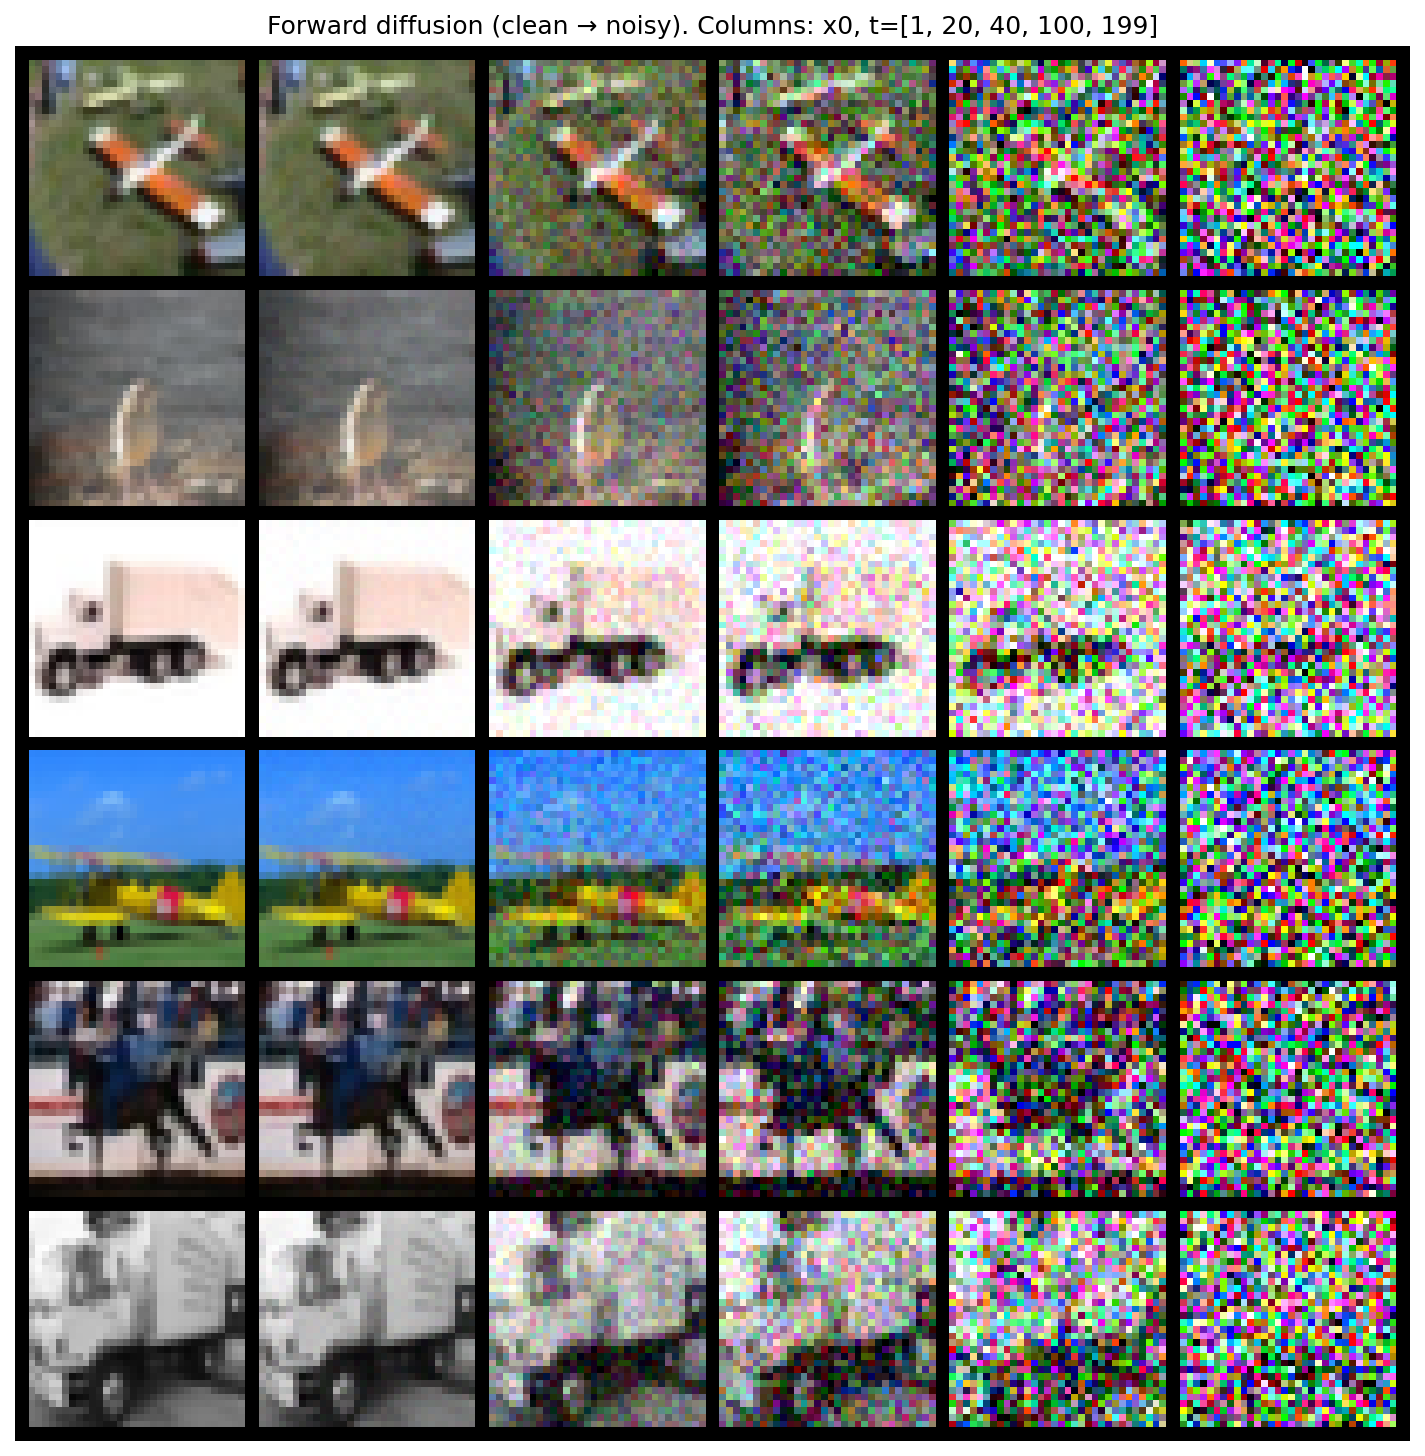

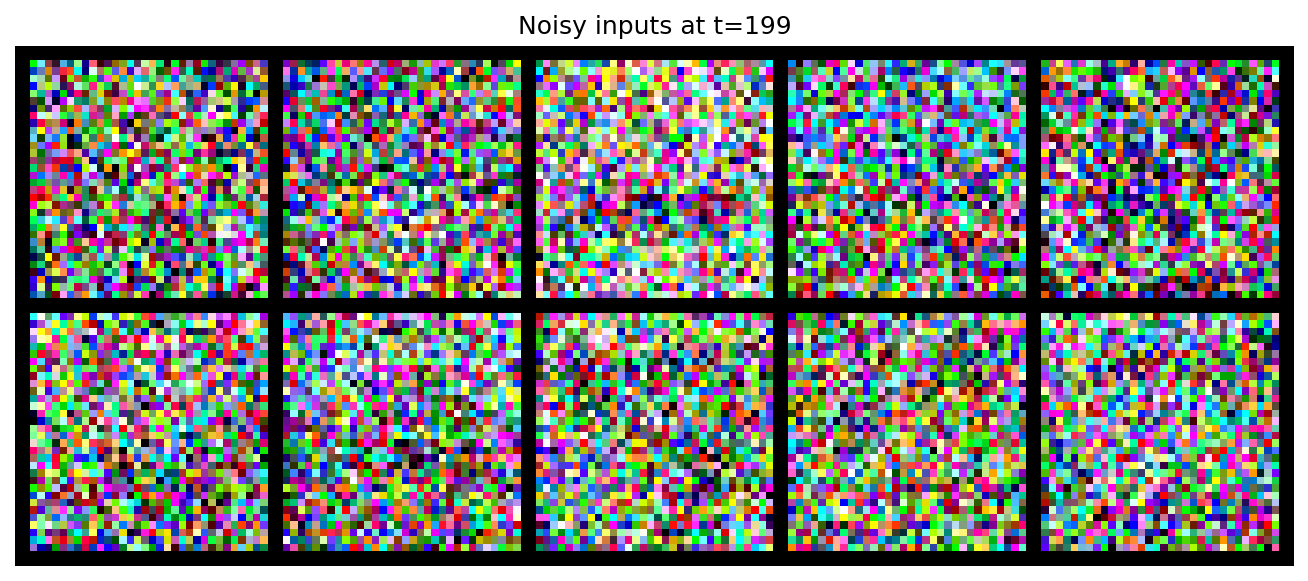

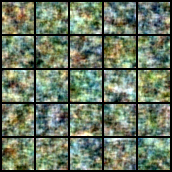

In [ ]:
import glob, os
from IPython.display import display, Image, HTML
imgs = sorted(glob.glob("./outputs_color/*.png"))
display(HTML("<h3>Saved outputs</h3>"))
for p in imgs:
    display(HTML(os.path.basename(p)))
    display(Image(filename=p))


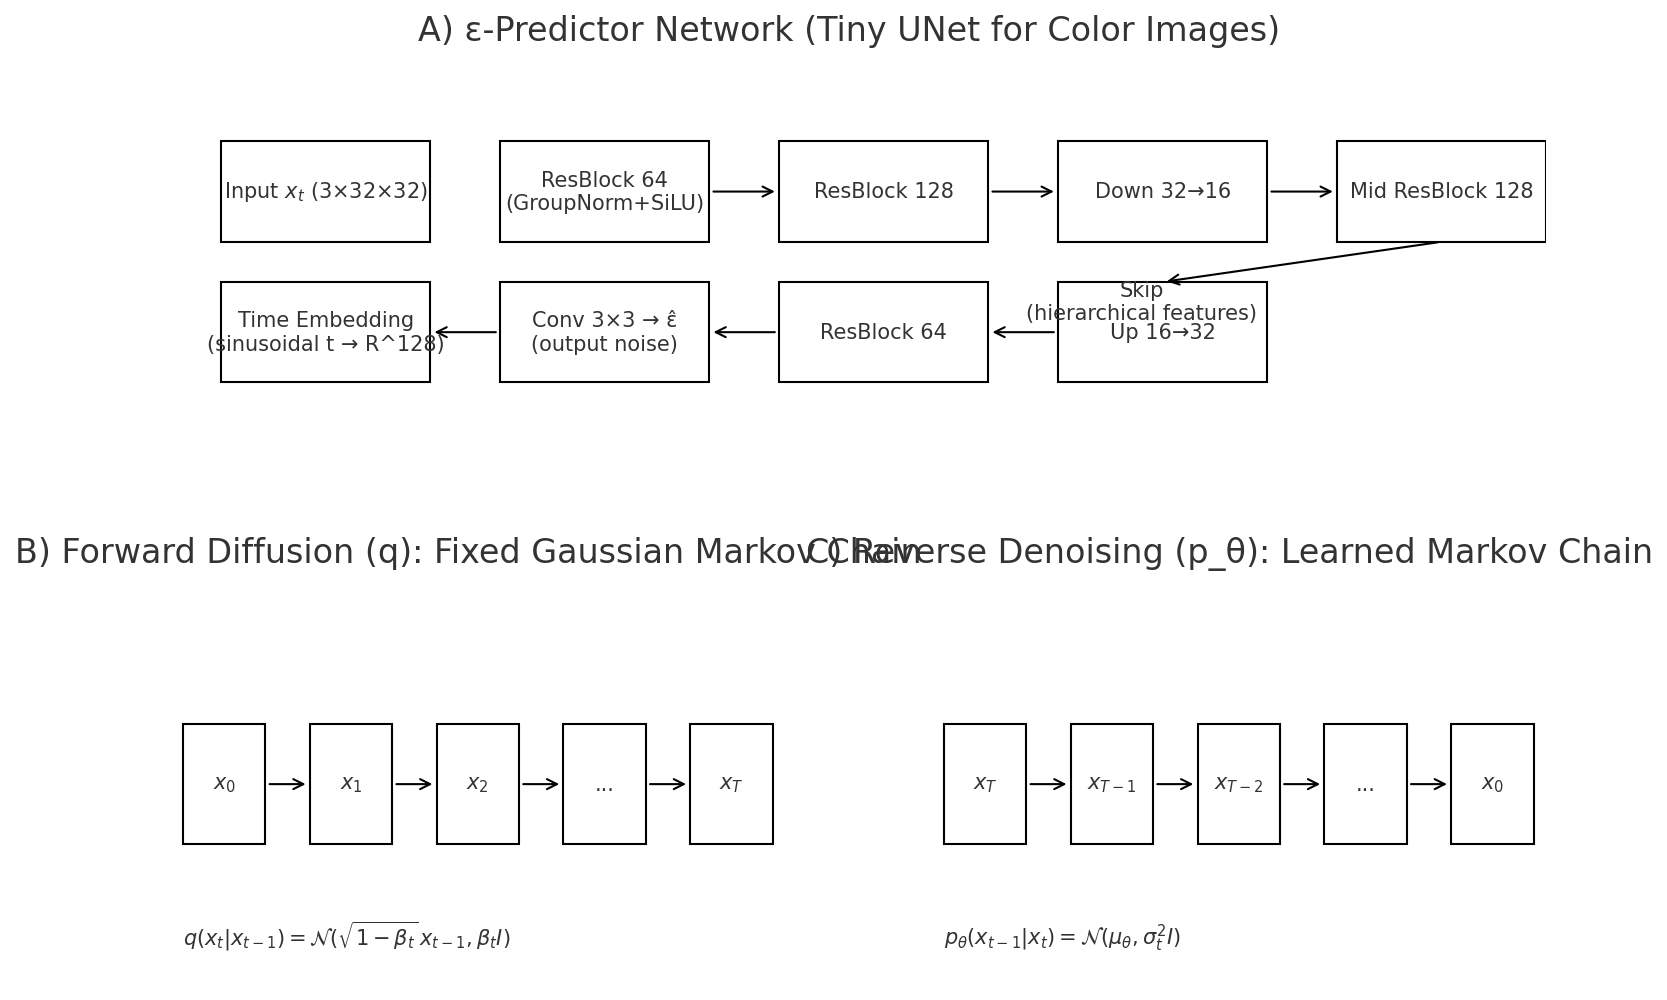

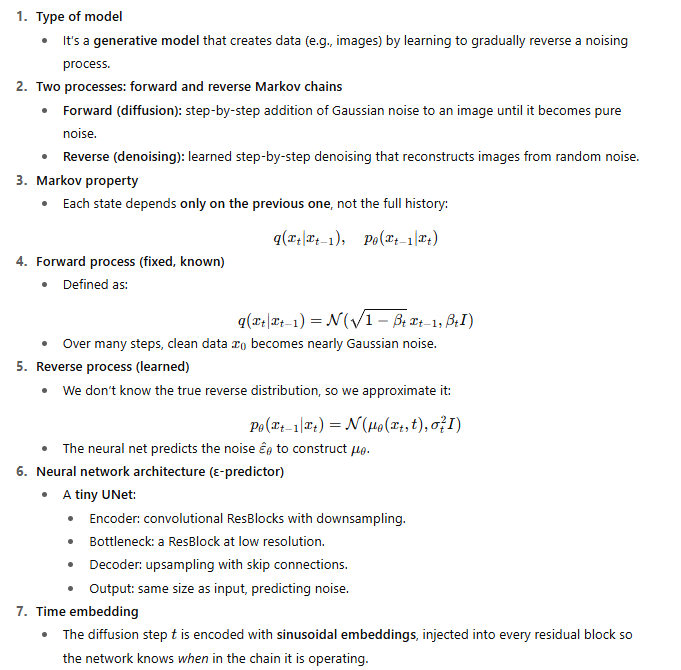

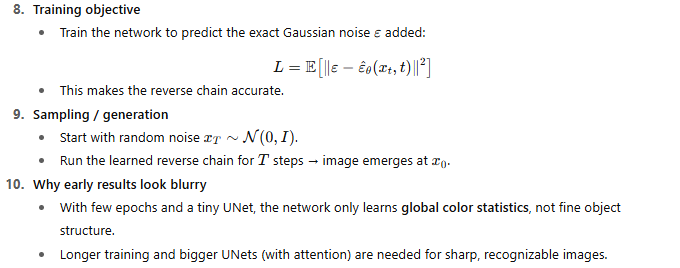